In [2]:
import pandas as pd
import matplotlib.pylab as plt

In [3]:
df = pd.read_parquet('../data/processed/clean_data.parquet')

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2898464 entries, 0 to 2898463
Data columns (total 8 columns):
 #   Column      Dtype         
---  ------      -----         
 0   permno      int32         
 1   yyyymm      int32         
 2   BM          float64       
 3   EP          float64       
 4   date        datetime64[ns]
 5   ret         float64       
 6   BM_missing  int64         
 7   EP_missing  int64         
dtypes: datetime64[ns](1), float64(3), int32(2), int64(2)
memory usage: 154.8 MB


In [4]:
df.index = df['date']
df = df.sort_index()

df.head()

,permno,yyyymm,BM,EP,date,ret,BM_missing,EP_missing
date,,,,,,,,
1950-12-31,18163,195012,0.05,0.142857,1950-12-31,-0.066772,0,0
1950-12-31,19975,195012,0.10,0.904762,1950-12-31,-0.013732,0,0
1950-12-31,10516,195012,0.60,0.476190,1950-12-31,0.075953,0,0
1950-12-31,24088,195012,0.50,0.428571,1950-12-31,0.116331,1,0
1950-12-31,19297,195012,1.00,0.952381,1950-12-31,0.011454,0,0


<Axes: >

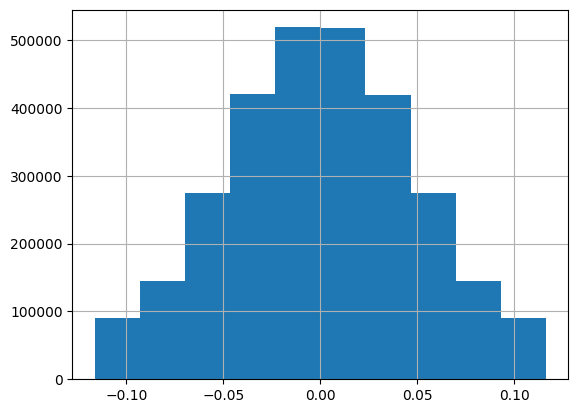

In [5]:
df['ret'].hist()

<Axes: >

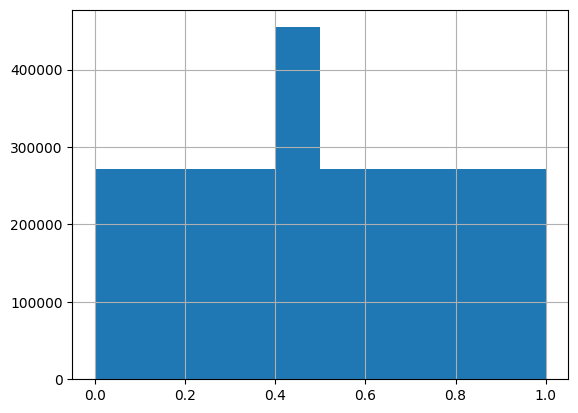

In [6]:
df['BM'].hist()

<Axes: >

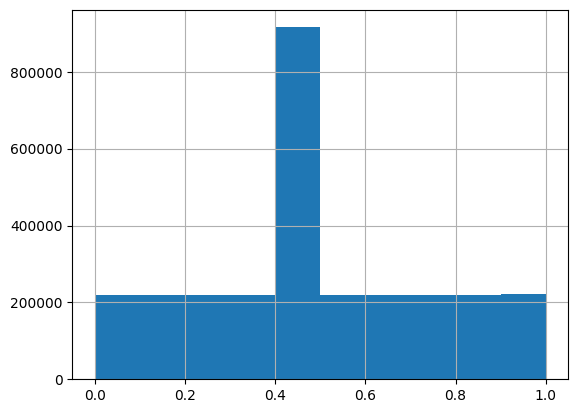

In [7]:
df['EP'].hist()

In [8]:
df[['BM','EP']].describe()

,BM,EP
count,2.898464e+06,2.898464e+06
mean,5.001534e-01,5.001534e-01
std,2.794018e-01,2.516751e-01
min,1.544640e-04,2.066116e-04
25%,2.670300e-01,3.291096e-01
50%,5.000000e-01,5.000000e-01
75%,7.333011e-01,6.712991e-01
max,1.000000e+00,1.000000e+00


<Axes: xlabel='date'>

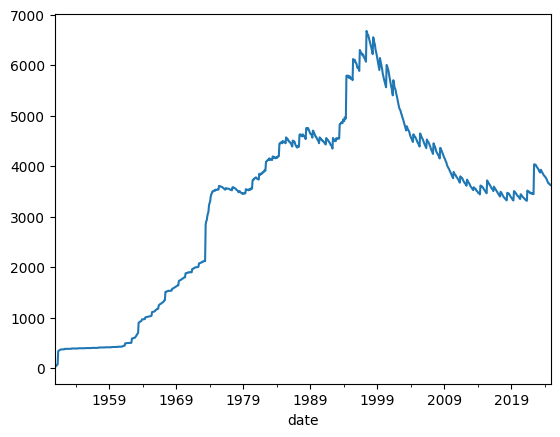

In [9]:
df.groupby(level=0)['permno'].nunique().plot()

<Axes: xlabel='date'>

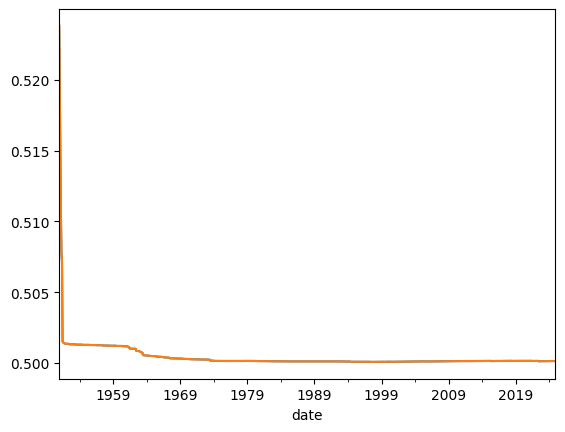

In [10]:
df.groupby(level=0)['BM'].mean().plot()
df.groupby(level=0)['EP'].mean().plot()

<Axes: xlabel='date'>

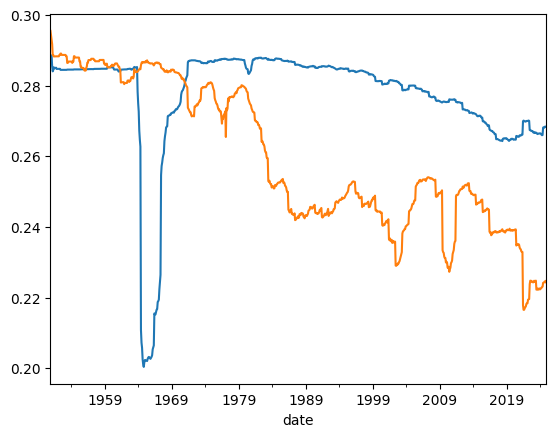

In [11]:
df.groupby(level=0)['BM'].std().plot()
df.groupby(level=0)['EP'].std().plot()

<Axes: xlabel='date'>

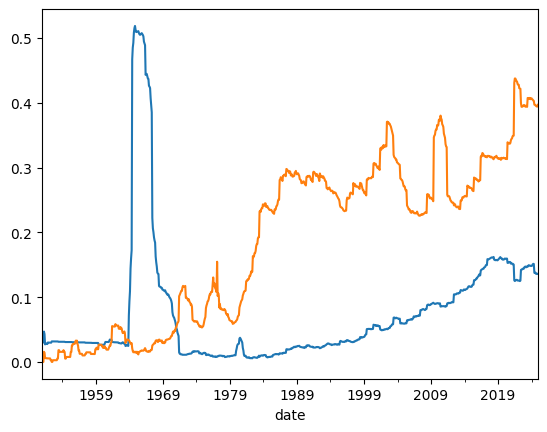

In [12]:
df['BM_missing'].groupby(level=0).mean().plot()
df['EP_missing'].groupby(level=0).mean().plot()

In [ ]:
df = pd.read_parquet('../data/processed/test_clean_data.parquet')

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 283380 entries, 0 to 283379
Data columns (total 100 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   stock_id                        283380 non-null  int32  
 1   date                            283380 non-null  object 
 2   Advt_12M_Usd                    283380 non-null  float64
 3   Advt_3M_Usd                     283380 non-null  float64
 4   Advt_6M_Usd                     283380 non-null  float64
 5   Asset_Turnover                  283380 non-null  float64
 6   Bb_Yld                          283380 non-null  float64
 7   Bv                              283380 non-null  float64
 8   Capex_Ps_Cf                     283380 non-null  float64
 9   Capex_Sales                     283380 non-null  float64
 10  Cash_Div_Cf                     283380 non-null  float64
 11  Cash_Per_Share                  283380 non-null  float64
 12  Cf_Sales       

283380

<Axes: >

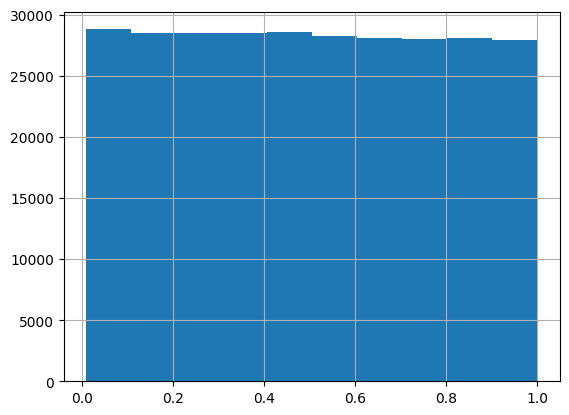

In [14]:
df['Ebit_Bv'].hist()

<Axes: >

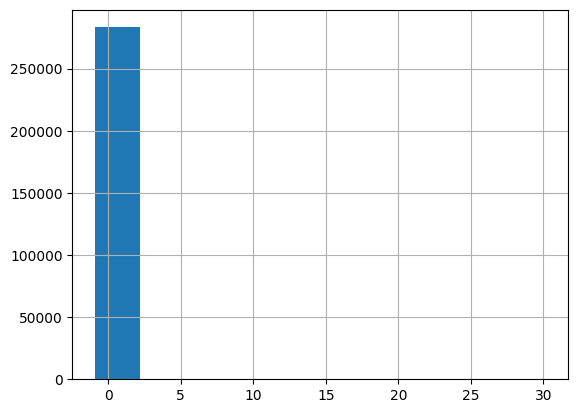

In [15]:
df['R1M_Usd'].hist()

<Axes: xlabel='date'>

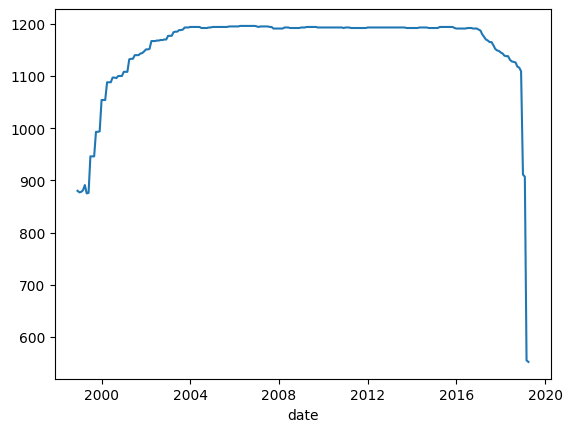

In [16]:
df.groupby('date')['stock_id'].nunique().plot()

In [17]:
groups = pd.to_datetime(df['date']).dt.year * 100 + pd.to_datetime(df['date']).dt.month

groups.min()

np.int32(199811)

In [18]:
print(df.head())
print(df.dtypes)
print(df.shape)

   stock_id        date  Advt_12M_Usd  Advt_3M_Usd  Advt_6M_Usd  \
0        13  2006-12-31          0.25         0.33         0.27   
1        13  2007-01-31          0.25         0.32         0.28   
2        13  2007-02-28          0.26         0.30         0.30   
3        17  2015-03-31          0.73         0.64         0.70   
4        17  2015-04-30          0.72         0.62         0.66   

   Asset_Turnover  Bb_Yld    Bv  Capex_Ps_Cf  Capex_Sales  ...  Total_Capital  \
0            0.22    0.33  0.01         0.13         0.84  ...           0.02   
1            0.22    0.40  0.01         0.13         0.84  ...           0.02   
2            0.22    0.15  0.01         0.13         0.84  ...           0.02   
3            0.40    0.47  0.01         0.70         0.74  ...           0.40   
4            0.40    0.46  0.01         0.70         0.74  ...           0.40   

   Total_Debt  Total_Debt_Capital  Total_Liabilities_Total_Assets  Vol1Y_Usd  \
0        0.27                 